In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# parámetros físicos
R = 0.1          # radio tubería (m)
mu = 0.001       # viscosidad agua (Pa.s)
rho = 1000       # densidad (kg/m3)
dpdx = -100      # gradiente presión (Pa/m)
gx = 0           # gravedad en dirección x

G = dpdx - rho * gx

# discretización radial
N = 100
r = np.linspace(0, R, N)
dr = r[1] - r[0]

A = np.zeros((N, N))
b = np.zeros(N)

# interior
for i in range(1, N-1):
    
    A[i,i-1] = 1/dr**2 - 1/(2*r[i]*dr)
    A[i,i]   = -2/dr**2
    A[i,i+1] = 1/dr**2 + 1/(2*r[i]*dr)
    
    b[i] = G/mu

# condición centro (simetría)
A[0,0] = -1
A[0,1] = 1
b[0] = 0

# condición pared
A[N-1,N-1] = 1
b[N-1] = 0

# resolver sistema
u = np.linalg.solve(A,b)

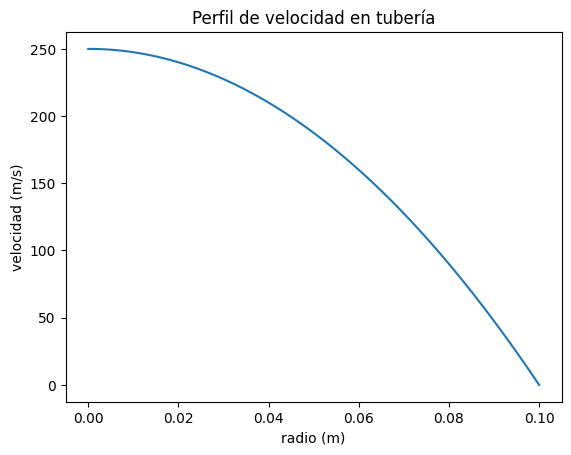

In [3]:
# gráfica
plt.plot(r,u)
plt.xlabel("radio (m)")
plt.ylabel("velocidad (m/s)")
plt.title("Perfil de velocidad en tubería")
plt.show()